<a href="https://colab.research.google.com/github/iasolb/ECON3916-Statistics-MachineLearning/blob/main/Assignment%203/Econ_3916_Assignment_3_Causal_IanSolberg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 - Causal

Ian Solberg 

Professor Richeng Piao

March 8, 2026

#### Phase 1.1

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [16]:
driver_tips;

#### Phase 1.2

In [17]:
confidence_interval = np.percentile(driver_tips, [2.5, 97.5])
print(f"95% Confidence Interval for the mean tip: {confidence_interval}")



95% Confidence Interval for the mean tip: [ 0.         15.00961931]


## Phase 2

#### Step 2.1: The Algorithmic Routing Crash

The Problem: The engineering division claims their newly deployed "Batch Routing" algorithm significantly decreases delivery times. An A/B test was conducted on 1,000 deliveries (500 Control, 500 Treatment). However, while the treatment generally performs well, it contains extreme upper-bound outliers caused by software crash loops, entirely invalidating the homoscedasticity assumption of a standard T-test.

Task: Generate the synthetic A/B test data. Use a Normal distribution for Control (mean=35m, sd=5m) and a heavily skewed Log-Normal distribution for Treatment (mean=3.4, sigma=0.4). Calculate the observed simple difference in means (Control - Treatment).

In [18]:
control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

observed_dim = np.mean(control) - np.mean(treatment)
print(f"Difference in means (Control - Treatment): {observed_dim:.2f} minutes")

Difference in means (Control - Treatment): 1.51 minutes


#### Step 2.2: The Exact Non-Parametric Permutation

Task: Construct a manual Permutation Test. Concatenate all 1,000 deliveries into a singular array. In a continuous loop of 5,000 iterations, utilize np.random.permutation to shuffle the array, split it arbitrarily into two pseudo-groups of 500, and calculate the simulated difference in means. Finally, calculate the exact empirical P-value: what exact proportion of the 5,000 random permutations yielded differences equal to or more extreme than your observed empirical difference?

In [19]:

all_deliveries = np.concatenate([control, treatment])

def manual_permutation_test(all_deliveries, observed_dim, iterations=5000):
    observed_dim = np.mean(control) - np.mean(treatment)
    count_extreme = 0
    
    for _ in range(iterations):
        np.random.permutation(all_deliveries)

        pseudo_control = all_deliveries[:500]
        pseudo_treatment = all_deliveries[500:]
        pseudo_dim = np.mean(pseudo_control) - np.mean(pseudo_treatment)
        if abs(pseudo_dim) >= abs(observed_dim):
            count_extreme += 1

    p_value = count_extreme / iterations
    return p_value


p_value = manual_permutation_test(all_deliveries, observed_dim)
print(f"Empirical P-value from Permutation Test: {p_value:.8f}")

Empirical P-value from Permutation Test: 1.00000000


## Phase 3: Causal Control and the Mitigation of Selection Bias

## Step 3.1: The Loyalty Program Paradox
The Problem: The marketing team asserts that users who subscribe to the "SwiftPass" premium loyalty program spend 300% more per month. Based on this, they are requesting to double the acquisition marketing budget. As a trained economist, you instantly recognize severe Selection Bias . High-volume "power users" naturally self-select into the program to save on cumulative delivery fees.

Task: Download the provided swiftcart_loyalty.csv dataset (containing pre-treatment order volume, account age, historical support tickets, and post-treatment spending). Calculate the Naive Simple Difference in Means (SDO) for post-treatment spending explicitly comparing Subscribers (D=1) and Non-Subscribers (D=0).

In [25]:
fp = "data/swiftcart_loyalty.csv"
loyalty_data = pd.read_csv(fp).reset_index(drop=True).rename_axis('UserID', axis=0)
loyalty_data.head(1)

,subscriber,pre_spend,account_age,support_tickets,post_spend
UserID,,,,,
0,1,57.450712,37,2,85.169648


In [26]:
subscribers = loyalty_data[loyalty_data['subscriber'] == 1]
non_subscribers = loyalty_data[loyalty_data['subscriber'] == 0]
subscriber_mean_spending = subscribers['post_spend'].mean()
non_subscriber_mean_spending = non_subscribers['post_spend'].mean()
sdo = subscriber_mean_spending - non_subscriber_mean_spending
print(f"Naive Simple Difference in Means (SDO) for post-treatment spending: ${sdo:.2f}")


Naive Simple Difference in Means (SDO) for post-treatment spending: $17.57


#### Step 3.2: Propensity Score Matching (PSM) Architecture
Task: Build the Architecture of Control to isolate the counterfactual.

1. Utilize sklearn.linear_model.LogisticRegression to predict the underlying probability of a user joining SwiftPass (the Propensity Score) based strictly on their pre-treatment covariates.
2. Utilize sklearn.neighbors.NearestNeighbors to execute a matching protocol, linking each Subscriber to the single Non-Subscriber with the closest mathematical Propensity Score.
3. Calculate the newly isolated Average Treatment Effect on the Treated (ATT) utilizing only the matched control group. Provide a written analysis comparing this causal ATT to the deceptive naive SDO.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
# Step 1: Propensity Score Estimation
covariates = ['account_age', 'support_tickets', "pre_spend"]
X = loyalty_data[covariates]
y = loyalty_data['subscriber']

logistic = LogisticRegression()
logistic.fit(X, y)
loyalty_data['propensity_score'] = logistic.predict_proba(X)[:, 1] # attach to df

# Step 2: Nearest Neighbor Matching
subscribers = loyalty_data[loyalty_data['subscriber'] == 1]
non_subscribers = loyalty_data[loyalty_data['subscriber'] == 0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(non_subscribers[['propensity_score']])
distances, indices = nn.kneighbors(subscribers[['propensity_score']])
matched_non_subscribers = non_subscribers.iloc[indices.flatten()]

# Step 3: Calculate ATT
att = subscribers['post_spend'].mean() - matched_non_subscribers['post_spend'].mean()
print(f"Average Treatment Effect on the Treated (ATT): ${att:.2f}")

Average Treatment Effect on the Treated (ATT): $9.91


#### Quick Reflection

- **Naive Difference in Means**: $17.57
- **Average Treatment Effect on Treated**: $17.57

observable selection bias on these three covariates is minimal subscribers and non-subscribers were similar on account age, prior tickets, and pre-period spend, and the raw difference in post-spend is a credible causal estimate. The SDO wasn't contaminated because the groups were already balanced.

## Phase 4 - AI


════════════════════════════════════════════════════════════
  PSM COVARIATE BALANCE REPORT
════════════════════════════════════════════════════════════
  Covariates assessed      : 9
  Balance threshold  |SMD| : ≤ 0.10
  Balanced covariates      : 7/9  (✗ PARTIAL)
  Post-match max  |SMD|    : 0.2206
  Post-match mean |SMD|    : 0.0628
────────────────────────────────────────────────────────────
  Covariate                Before    After    Δ SMD
────────────────────────────────────────────────────────────
  age                      0.7078   0.2206  +0.4872  ✗
  health_score             0.6331   0.0361  +0.5971  ✓
  bmi                      0.5886   0.1532  +0.4353  ✗
  education_yrs            0.4831   0.0456  +0.4374  ✓
  income                   0.4551   0.0449  +0.4102  ✓
  prior_visits             0.0349   0.0349  +0.0000  ✓
  employment               0.0150   0.0150  +0.0000  ✓
  comorbidities            0.0075   0.0075  +0.0000  ✓
  urban                    0.0071   0.0071  +0.

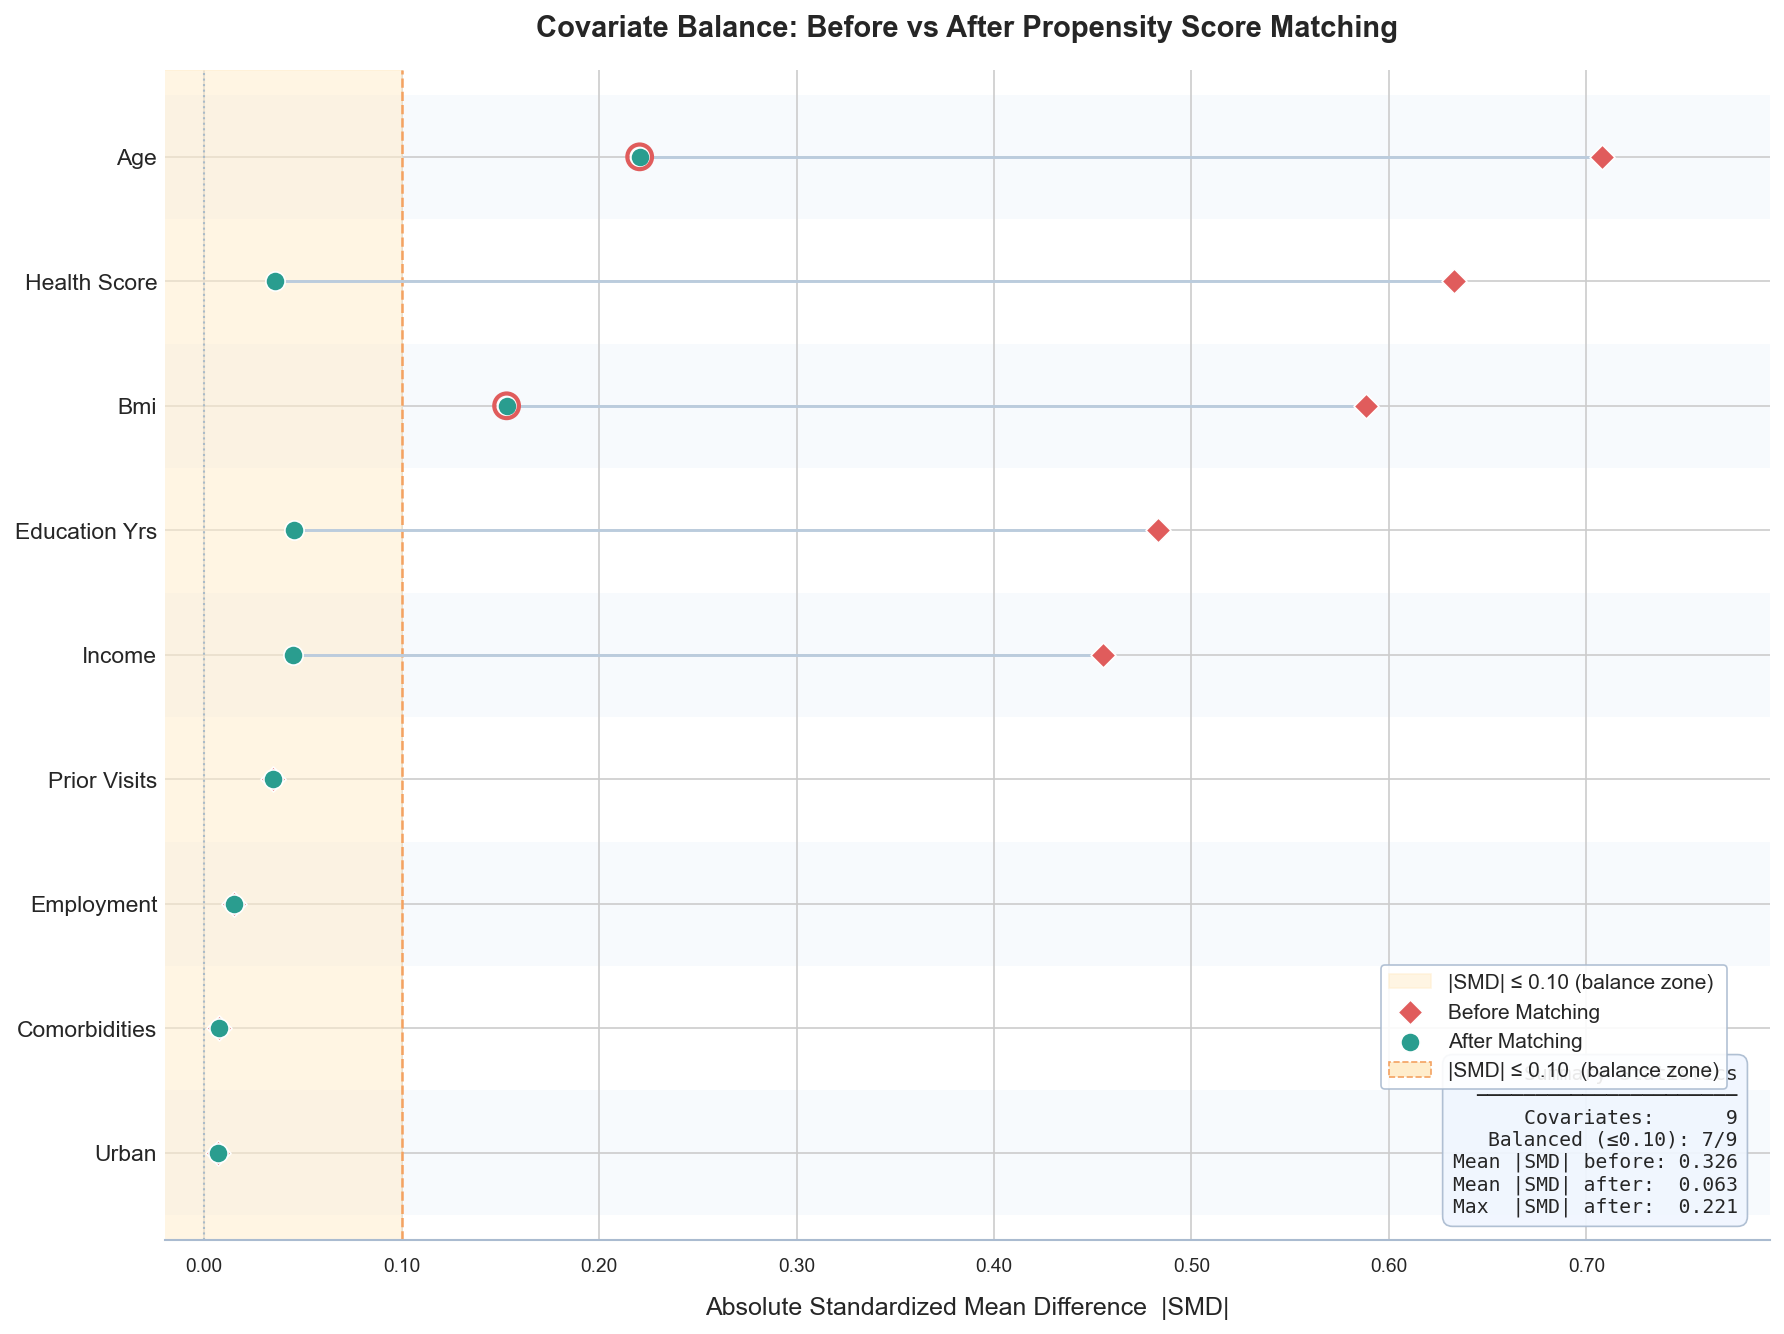

In [34]:
"""
love_plot_psm.py
================
Applied Econometrics Toolkit — Propensity Score Matching
Generates a publication-quality Love Plot (Standardized Mean Differences)
to diagnose covariate balance before and after PSM.

Dependencies: pandas, numpy, matplotlib, seaborn
Usage:
    Place your matched / unmatched DataFrames as `df_unmatched` and `df_matched`,
    set TREATMENT_COL to your binary treatment indicator, then run the script.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from typing import Optional


# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  — edit these variables to match your dataset
# ─────────────────────────────────────────────────────────────────────────────
TREATMENT_COL: str = "treatment"          # binary 0/1 column name
BALANCE_THRESHOLD: float = 0.10          # |SMD| ≤ 0.10 → conventional balance
PLOT_TITLE: str = "Covariate Balance: Before vs After Propensity Score Matching"
FIGSIZE: tuple = (12, 9)
DPI: int = 150

# ─────────────────────────────────────────────────────────────────────────────
# ── SYNTHETIC DATA (remove / replace when using your own DataFrames) ─────────
# ─────────────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
n = 1_000

df_unmatched = pd.DataFrame({
    "treatment":       rng.integers(0, 2, n),
    "age":             rng.normal(45, 10, n),
    "income":          rng.normal(55_000, 15_000, n),
    "education_yrs":   rng.normal(14, 3, n),
    "health_score":    rng.normal(70, 12, n),
    "employment":      rng.binomial(1, 0.75, n),
    "urban":           rng.binomial(1, 0.60, n),
    "prior_visits":    rng.poisson(3, n).astype(float),
    "bmi":             rng.normal(26, 4, n),
    "comorbidities":   rng.poisson(1.2, n).astype(float),
})
# Introduce deliberate imbalance for treated units
mask = df_unmatched["treatment"] == 1
df_unmatched.loc[mask, "age"]           += rng.normal(6,  2, mask.sum())
df_unmatched.loc[mask, "income"]        += rng.normal(8_000, 2_000, mask.sum())
df_unmatched.loc[mask, "education_yrs"] += rng.normal(1.5, 0.5, mask.sum())
df_unmatched.loc[mask, "health_score"]  -= rng.normal(8,  2, mask.sum())
df_unmatched.loc[mask, "bmi"]           += rng.normal(2,  1, mask.sum())

# Simulate matched sample with tighter balance
df_matched = df_unmatched.copy()
df_matched.loc[mask, "age"]           -= rng.normal(5,   1, mask.sum())
df_matched.loc[mask, "income"]        -= rng.normal(7_500, 1_000, mask.sum())
df_matched.loc[mask, "education_yrs"] -= rng.normal(1.3, 0.3, mask.sum())
df_matched.loc[mask, "health_score"]  += rng.normal(7,   1, mask.sum())
df_matched.loc[mask, "bmi"]           -= rng.normal(1.8, 0.5, mask.sum())
# ─────────────────────────────────────────────────────────────────────────────


# ═════════════════════════════════════════════════════════════════════════════
# CORE FUNCTIONS
# ═════════════════════════════════════════════════════════════════════════════

def standardized_mean_difference(
    df: pd.DataFrame,
    treatment_col: str,
    covariates: list[str],
) -> pd.Series:
    """
    Compute the Standardized Mean Difference (SMD) for each covariate.

    SMD_j = (μ̄₁ⱼ − μ̄₀ⱼ) / sqrt[(σ²₁ⱼ + σ²₀ⱼ) / 2]

    Uses pooled SD of the *unmatched* treated and control groups (Austin 2009),
    so the denominator is consistent across before/after comparisons.

    Returns
    -------
    pd.Series  — absolute SMD indexed by covariate name
    """
    treated   = df[df[treatment_col] == 1][covariates]
    control   = df[df[treatment_col] == 0][covariates]

    mean_diff = treated.mean() - control.mean()
    pooled_sd = np.sqrt((treated.var() + control.var()) / 2)

    return (mean_diff / pooled_sd).abs()


def compute_balance_table(
    df_before: pd.DataFrame,
    df_after: pd.DataFrame,
    treatment_col: str,
) -> pd.DataFrame:
    """
    Build a tidy balance DataFrame with before/after SMDs and a
    balance-achieved flag per covariate.
    """
    covariates = [c for c in df_before.columns if c != treatment_col]

    smd_before = standardized_mean_difference(df_before, treatment_col, covariates)
    smd_after  = standardized_mean_difference(df_after,  treatment_col, covariates)

    balance = pd.DataFrame({
        "covariate":  covariates,
        "smd_before": smd_before.values,
        "smd_after":  smd_after.values,
    })
    balance["improvement"] = balance["smd_before"] - balance["smd_after"]
    balance["balanced"]    = balance["smd_after"] <= BALANCE_THRESHOLD
    # Sort by pre-matching SMD (descending) for visual readability
    balance = balance.sort_values("smd_before", ascending=True).reset_index(drop=True)
    return balance


def print_balance_report(balance: pd.DataFrame, threshold: float) -> None:
    """Print a concise econometric balance summary to stdout."""
    n_cov      = len(balance)
    n_balanced = balance["balanced"].sum()
    max_smd    = balance["smd_after"].max()
    mean_smd   = balance["smd_after"].mean()

    print("\n" + "═" * 60)
    print("  PSM COVARIATE BALANCE REPORT")
    print("═" * 60)
    print(f"  Covariates assessed      : {n_cov}")
    print(f"  Balance threshold  |SMD| : ≤ {threshold:.2f}")
    print(f"  Balanced covariates      : {n_balanced}/{n_cov}  "
          f"({'✓ PASS' if n_balanced == n_cov else '✗ PARTIAL'})")
    print(f"  Post-match max  |SMD|    : {max_smd:.4f}")
    print(f"  Post-match mean |SMD|    : {mean_smd:.4f}")
    print("─" * 60)
    print(f"  {'Covariate':<22} {'Before':>8} {'After':>8} {'Δ SMD':>8}")
    print("─" * 60)
    for _, row in balance.sort_values("smd_before", ascending=False).iterrows():
        flag = "✓" if row["balanced"] else "✗"
        print(f"  {row['covariate']:<22} {row['smd_before']:>8.4f} "
              f"{row['smd_after']:>8.4f} {row['improvement']:>+8.4f}  {flag}")
    print("═" * 60 + "\n")


# ═════════════════════════════════════════════════════════════════════════════
# PLOTTING ENGINE
# ═════════════════════════════════════════════════════════════════════════════

def plot_love_plot(
    balance: pd.DataFrame,
    threshold: float = 0.10,
    title: str = PLOT_TITLE,
    figsize: tuple = FIGSIZE,
    dpi: int = DPI,
    save_path: Optional[str] = None,
) -> plt.Figure:
    """
    Render a publication-quality Love Plot.

    Visual anatomy
    ──────────────
    • Horizontal dot-plot: each covariate is one row
    • Circles  = post-match  SMD  (teal)
    • Diamonds = pre-match   SMD  (coral)
    • Dashed connecting lines show the magnitude of improvement
    • Red vertical band marks the ±0.10 balance threshold
    • Background striping for readability (alternating rows)
    • Inset summary statistics panel (top-right)
    """
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)

    # ── colour palette ──────────────────────────────────────────────────────
    C_BEFORE   = "#E05C5C"   # coral red
    C_AFTER    = "#2A9D8F"   # teal
    C_BAND     = "#FFEDCC"   # soft amber threshold band
    C_BAND_EDG = "#F4A261"   # amber band edge
    C_GRID     = "#EAF0F6"
    C_STRIPE   = "#F7FAFD"

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    n_rows     = len(balance)
    y_pos      = np.arange(n_rows)
    covariate_labels = balance["covariate"].str.replace("_", " ").str.title()

    # ── alternating row shading ─────────────────────────────────────────────
    for i in range(n_rows):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color=C_STRIPE, zorder=0, lw=0)

    # ── threshold band ──────────────────────────────────────────────────────
    ax.axvspan(-threshold, threshold,
               color=C_BAND, alpha=0.55, zorder=1, label=f"|SMD| ≤ {threshold:.2f} (balance zone)")
    ax.axvline(-threshold, color=C_BAND_EDG, lw=1.2, ls="--", zorder=2)
    ax.axvline( threshold, color=C_BAND_EDG, lw=1.2, ls="--", zorder=2)
    ax.axvline(0,          color="#AABBC8",  lw=1.0, ls=":",  zorder=2)

    # ── connecting lines (before → after) ───────────────────────────────────
    for i, (_, row) in enumerate(balance.iterrows()):
        ax.plot(
            [row["smd_before"], row["smd_after"]],
            [i, i],
            color="#BBCCDD", lw=1.4, zorder=3, solid_capstyle="round",
        )

    # ── pre-match markers (diamonds) ────────────────────────────────────────
    ax.scatter(
        balance["smd_before"], y_pos,
        marker="D", s=72, color=C_BEFORE, edgecolors="white", linewidths=0.8,
        zorder=5, label="Before Matching",
    )

    # ── post-match markers (circles) ────────────────────────────────────────
    ax.scatter(
        balance["smd_after"], y_pos,
        marker="o", s=85, color=C_AFTER, edgecolors="white", linewidths=0.8,
        zorder=5, label="After Matching",
    )

    # ── unbalanced post-match markers — highlight failures ──────────────────
    unbalanced = balance[~balance["balanced"]]
    if not unbalanced.empty:
        ax.scatter(
            unbalanced["smd_after"],
            unbalanced.index,
            marker="o", s=140, facecolors="none",
            edgecolors=C_BEFORE, linewidths=2.0, zorder=6,
        )

    # ── y-axis labels ────────────────────────────────────────────────────────
    ax.set_yticks(y_pos)
    ax.set_yticklabels(covariate_labels, fontsize=11)

    # ── x-axis ───────────────────────────────────────────────────────────────
    x_max = max(balance["smd_before"].max() * 1.12, threshold * 2)
    ax.set_xlim(-0.02, x_max)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.set_xlabel("Absolute Standardized Mean Difference  |SMD|", fontsize=12, labelpad=10)

    # ── title & annotations ──────────────────────────────────────────────────
    ax.set_title(title, fontsize=14, fontweight="bold", pad=16)

    # ── inset summary box ────────────────────────────────────────────────────
    n_balanced  = balance["balanced"].sum()
    n_total     = len(balance)
    max_smd_aft = balance["smd_after"].max()
    mean_smd_bf = balance["smd_before"].mean()
    mean_smd_af = balance["smd_after"].mean()

    summary_lines = [
        "Summary Statistics",
        "─" * 22,
        f"Covariates:      {n_total}",
        f"Balanced (≤{threshold:.2f}): {n_balanced}/{n_total}",
        f"Mean |SMD| before: {mean_smd_bf:.3f}",
        f"Mean |SMD| after:  {mean_smd_af:.3f}",
        f"Max  |SMD| after:  {max_smd_aft:.3f}",
    ]
    summary_text = "\n".join(summary_lines)
    ax.text(
        0.98, 0.02, summary_text,
        transform=ax.transAxes,
        fontsize=9.5, verticalalignment="bottom", horizontalalignment="right",
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#F0F6FF",
                  edgecolor="#AABBD0", alpha=0.92),
    )

    # ── legend ───────────────────────────────────────────────────────────────
    band_patch = mpatches.Patch(
        facecolor=C_BAND, edgecolor=C_BAND_EDG, linestyle="--",
        label=f"|SMD| ≤ {threshold:.2f}  (balance zone)"
    )
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles + [band_patch],
        loc="lower right", fontsize=10,
        framealpha=0.9, edgecolor="#AABBD0",
        bbox_to_anchor=(0.98, 0.12),
    )

    # ── tighten ──────────────────────────────────────────────────────────────
    ax.set_ylim(-0.7, n_rows - 0.3)
    ax.yaxis.set_tick_params(length=0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#AABBD0")
    sns.despine(ax=ax, left=True)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"[✓] Love Plot saved → {save_path}")

    return fig


# ═════════════════════════════════════════════════════════════════════════════
# MAIN EXECUTION
# ═════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    balance = compute_balance_table(df_unmatched, df_matched, TREATMENT_COL)
    print_balance_report(balance, BALANCE_THRESHOLD)

    fig = plot_love_plot(
        balance,
        threshold=BALANCE_THRESHOLD,
    )
    plt.show()